In [1]:
import pygeotools
import pygeopinn

In [2]:
pygeo = pygeotools.pygeotools()
pinns = pygeopinn.pygeopinn()

pygeotools was initialized with `verbose=True`.
The library was successfully initialized.


In [3]:
# Loading the model
pygeo.loadModel("geodynamo", "pygeodyn_hdf5", "../geodynamo.hdf5")

In [4]:
pygeo.setGrid("5deg")

_, (thetas, phis) = pygeo.getCurrentGrid()

context = {"lmax": 13, "r": pygeo.constants["rCore"]}

MF = pygeo.addMeasure("geodynamo", "MF", context)
SV = pygeo.addMeasure("geodynamo", "SV", context)
U = pygeo.addMeasure("geodynamo", "U", context)

dBrdt = SV[-1, ..., 0]
Br = MF[-1, ..., 0]
Uθ = U[-1, ..., 1]
Uφ = U[-1, ..., 2]

13


In [28]:
observations = {
    "dbrdt": dBrdt, "br": Br, "uθ": Uθ, "uφ": Uφ
}

In [5]:
pinns.set_grid(thetas, phis)
pinns.set_observation("br", Br)
pinns.set_observation("dbrdt", dBrdt)

The grid was successfully set.
The observation br was successfully added.
The observation dbrdt was successfully added.


In [6]:
pinns.train(10000)

Everything is ready for the training.


100.00% (00:00 remaining) | Loss = 5.965E-02


In [29]:
predictions = pinns.evaluate()

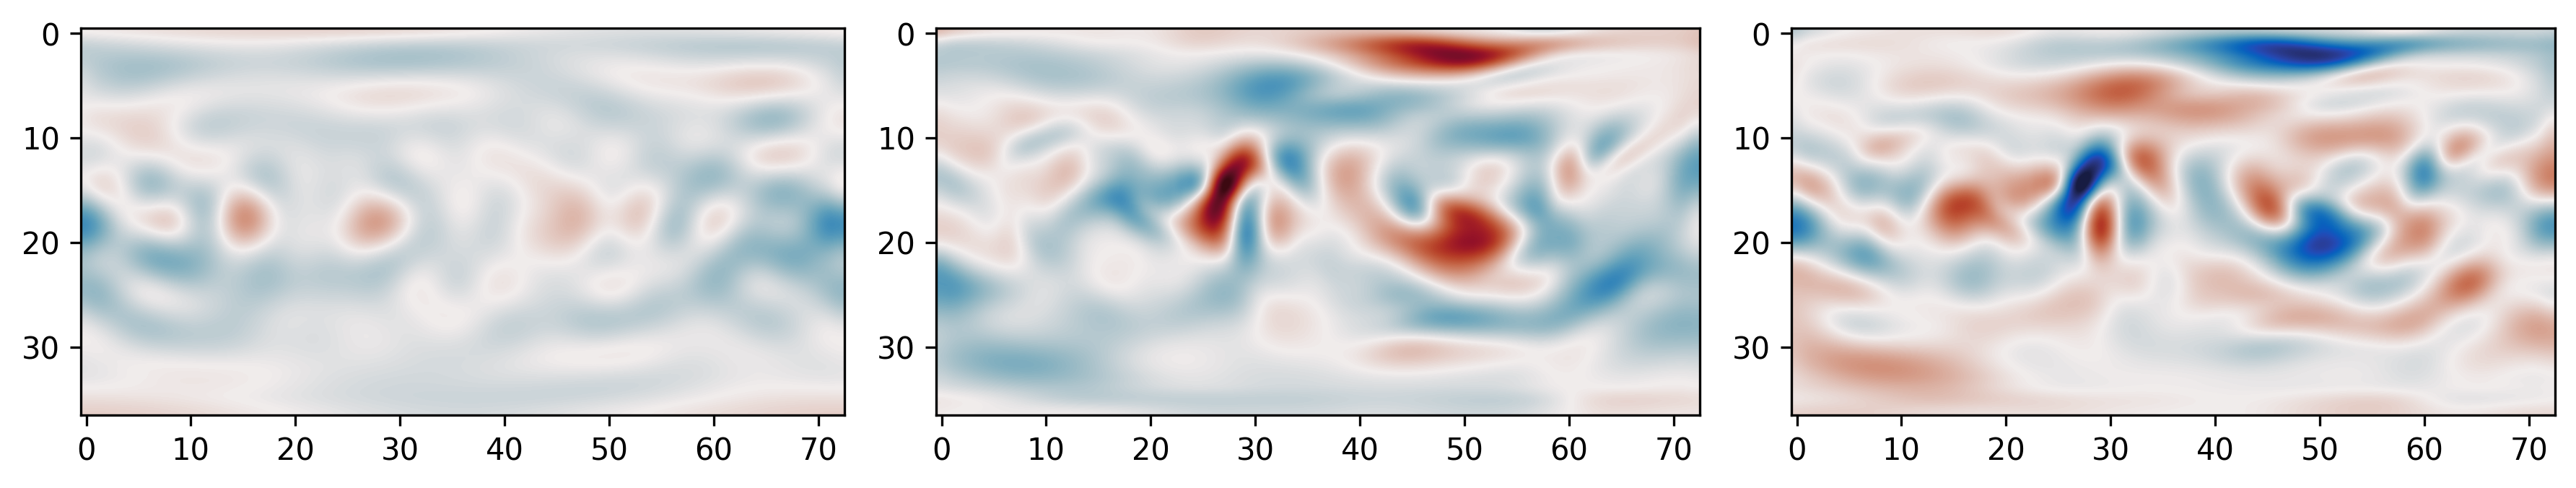

In [44]:
import matplotlib.pyplot as plt
import cmocean

quantity = "uφ"

fig, axes = plt.subplots(1, 3, dpi=300, figsize=(12, 5))

prediction = predictions[quantity]
observation = observations[quantity]

vmax = max(abs(prediction).max(), abs(observation).max())
kwargs = {"cmap": cmocean.cm.balance, "interpolation": "lanczos", "vmin": -vmax, "vmax": vmax}

axes[0].imshow(observation, **kwargs)
axes[1].imshow(prediction, **kwargs)
axes[2].imshow(observation - prediction, **kwargs)

plt.tight_layout()